<a href="https://colab.research.google.com/github/AnanyaAsthana/Digital-Image-Processing/blob/main/DIP_LAB_7%268.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from scipy.signal import convolve2d
from scipy.fft import fft2, ifft2, fftshift, ifftshift

/tmp/ipykernel_4853/3432648668.py:27: RuntimeWarning: divide by zero encountered in scalar divide
  H[u,v] = 1 / (1 + ((D*D0)/(D**2 - D0**2))**(2*n))


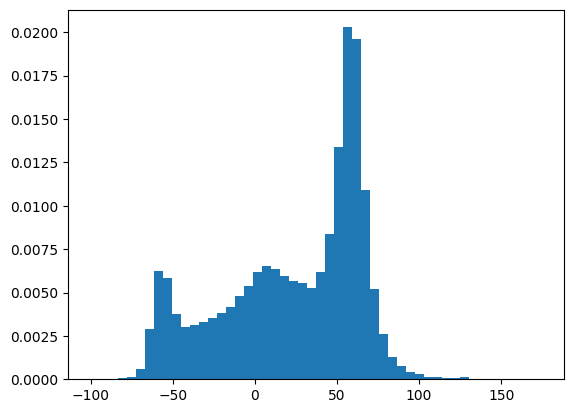

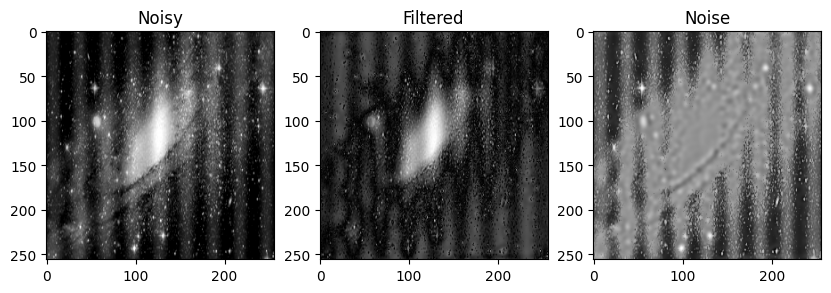

In [ ]:
img = cv2.imread('/content/image.jpg', 0)
img = cv2.resize(img, (256,256))

# Add periodic noise
rows, cols = img.shape
x = np.arange(cols)
y = np.arange(rows)
X, Y = np.meshgrid(x, y)

noise = 30 * np.sin(2 * np.pi * X / 30)
noisy = img + noise
noisy = np.clip(noisy, 0, 255)

# FFT
f = fftshift(fft2(noisy))

# Butterworth Bandpass
D0 = 20
n = 2
crow, ccol = rows//2, cols//2

H = np.zeros((rows, cols))
for u in range(rows):
    for v in range(cols):
        D = np.sqrt((u-crow)**2 + (v-ccol)**2)
        if D != 0:
            H[u,v] = 1 / (1 + ((D*D0)/(D**2 - D0**2))**(2*n))

filtered = np.abs(ifft2(ifftshift(f * H)))

# Extract noise
extracted_noise = noisy - filtered

# PDF
plt.hist(extracted_noise.ravel(), bins=50, density=True)

# Display
plt.figure(figsize=(10,6))
plt.subplot(131); plt.imshow(noisy, cmap='gray'); plt.title("Noisy")
plt.subplot(132); plt.imshow(filtered, cmap='gray'); plt.title("Filtered")
plt.subplot(133); plt.imshow(extracted_noise, cmap='gray'); plt.title("Noise")
plt.show()

In [ ]:
def salt_pepper(img, prob=0.05):
    noisy = img.copy()
    rand = np.random.rand(*img.shape)
    noisy[rand < prob/2] = 0
    noisy[rand > 1 - prob/2] = 255
    return noisy

img = cv2.imread('/content/image.jpg', 0)
noisy = salt_pepper(img)

Text(0.5, 1.0, 'Ideal Notch')

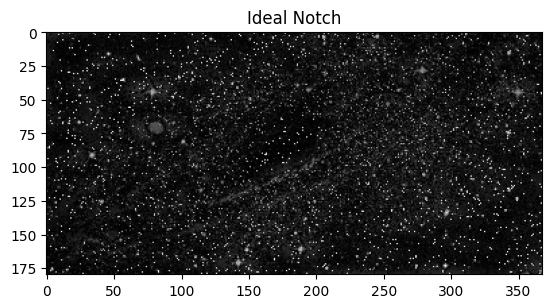

In [ ]:
def ideal_notch(shape, D0=10):
    rows, cols = shape
    mask = np.ones((rows, cols))
    center = (rows//2, cols//2)

    for u in range(rows):
        for v in range(cols):
            if np.sqrt((u-center[0])**2 + (v-center[1])**2) < D0:
                mask[u,v] = 0
    return mask

f = fftshift(fft2(noisy))
H = ideal_notch(noisy.shape)
res = np.abs(ifft2(ifftshift(f * H)))

plt.imshow(res, cmap='gray'); plt.title("Ideal Notch")

Text(0.5, 1.0, 'Gaussian Notch')

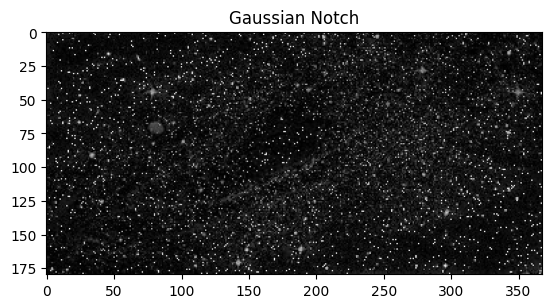

In [ ]:
def gaussian_notch(shape, D0=10):
    rows, cols = shape
    mask = np.zeros((rows, cols))
    center = (rows//2, cols//2)

    for u in range(rows):
        for v in range(cols):
            D = np.sqrt((u-center[0])**2 + (v-center[1])**2)
            mask[u,v] = 1 - np.exp(-(D**2)/(2*(D0**2)))
    return mask

H = gaussian_notch(noisy.shape)
res = np.abs(ifft2(ifftshift(f * H)))

plt.imshow(res, cmap='gray'); plt.title("Gaussian Notch")

Text(0.5, 1.0, 'Butterworth Notch')

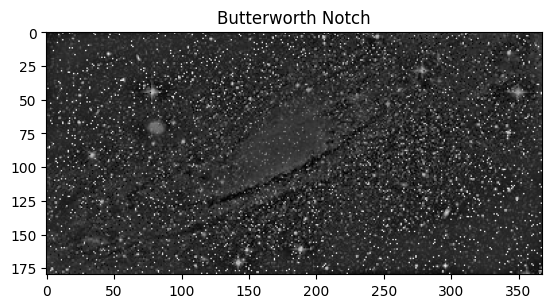

In [ ]:
def butterworth_notch(shape, D0=10, n=2):
    rows, cols = shape
    mask = np.ones((rows, cols))
    center = (rows//2, cols//2)

    for u in range(rows):
        for v in range(cols):
            D = np.sqrt((u-center[0])**2 + (v-center[1])**2)
            if D != 0:
                mask[u,v] = 1 / (1 + (D0/D)**(2*n))
    return mask

H = butterworth_notch(noisy.shape)
res = np.abs(ifft2(ifftshift(f * H)))

plt.imshow(res, cmap='gray'); plt.title("Butterworth Notch")

In [ ]:
img = cv2.imread('/content/image.jpg', 0)
noise = np.random.normal(0, 20, img.shape)
noisy = img + noise

Text(0.5, 1.0, 'Inverse Filter')

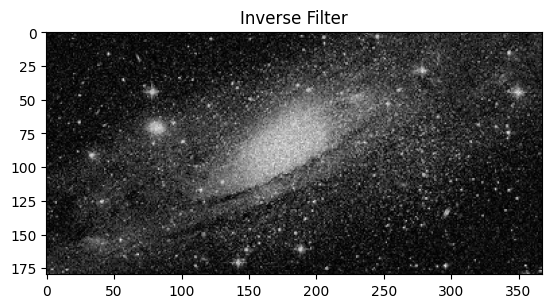

In [ ]:
f = fft2(noisy)
H = np.ones_like(f)  # assume blur = identity

inverse = np.abs(ifft2(f / (H + 1e-5)))

plt.imshow(inverse, cmap='gray'); plt.title("Inverse Filter")

Text(0.5, 1.0, 'Wiener Filter')

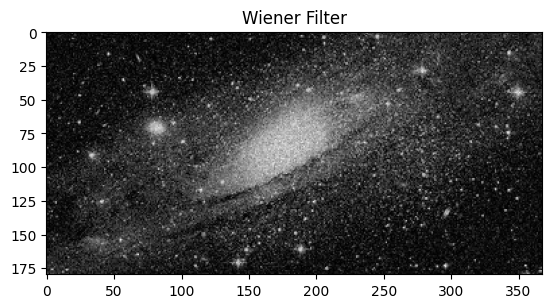

In [ ]:
def wiener_filter(img, K=0.01):
    f = fft2(img)
    H = np.ones_like(f)
    H_conj = np.conj(H)

    result = (H_conj / (np.abs(H)**2 + K)) * f
    return np.abs(ifft2(result))

wiener = wiener_filter(noisy)

plt.imshow(wiener, cmap='gray'); plt.title("Wiener Filter")

Text(0.5, 1.0, 'Point Detection')

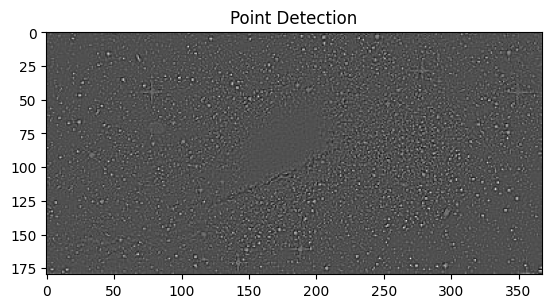

In [ ]:
# Point detection mask
point_mask = np.array([[-1,-1,-1],
                       [-1,8,-1],
                       [-1,-1,-1]])

result = convolve2d(img, point_mask, mode='same')
plt.imshow(result, cmap='gray'); plt.title("Point Detection")

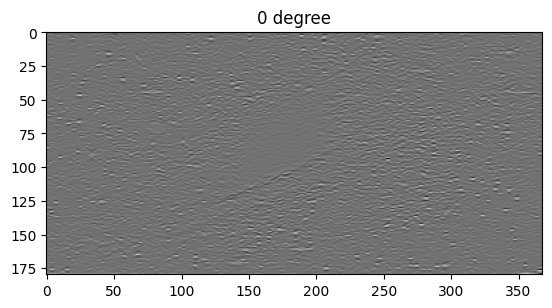

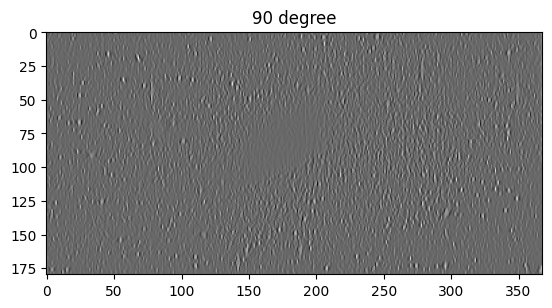

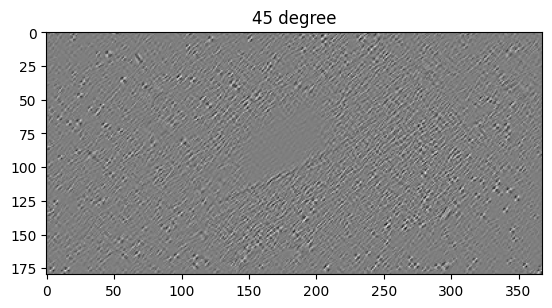

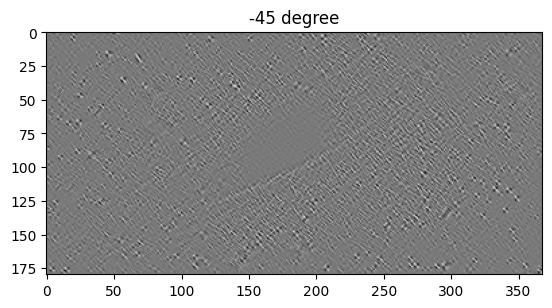

In [ ]:
masks = {
    "0": np.array([[-1,-1,-1],[2,2,2],[-1,-1,-1]]),
    "90": np.array([[-1,2,-1],[-1,2,-1],[-1,2,-1]]),
    "45": np.array([[-1,-1,2],[-1,2,-1],[2,-1,-1]]),
    "-45": np.array([[2,-1,-1],[-1,2,-1],[-1,-1,2]])
}

for k, m in masks.items():
    res = convolve2d(img, m, mode='same')
    plt.imshow(res, cmap='gray')
    plt.title(f"{k} degree")
    plt.show()

Text(0.5, 1.0, 'Laplacian')

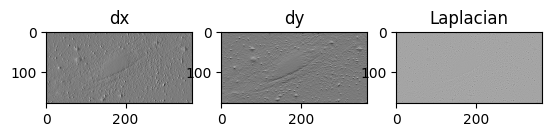

In [ ]:
# First derivative (Sobel)
sobelx = cv2.Sobel(img, cv2.CV_64F, 1, 0)
sobely = cv2.Sobel(img, cv2.CV_64F, 0, 1)

# Second derivative (Laplacian)
lap = cv2.Laplacian(img, cv2.CV_64F)

plt.subplot(131); plt.imshow(sobelx, cmap='gray'); plt.title("dx")
plt.subplot(132); plt.imshow(sobely, cmap='gray'); plt.title("dy")
plt.subplot(133); plt.imshow(lap, cmap='gray'); plt.title("Laplacian")

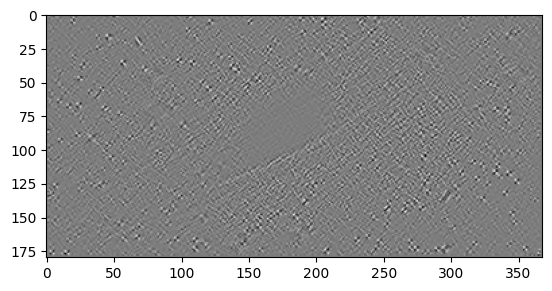

In [ ]:
edges = cv2.Sobel(img, cv2.CV_64F, 1, 1)
plt.imshow(edges, cmap='gray')

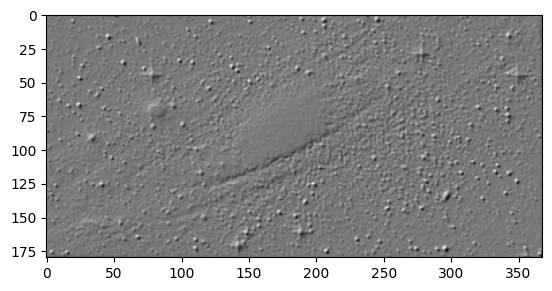

In [ ]:
kernelx = np.array([[1,0,-1],[1,0,-1],[1,0,-1]])
kernely = np.array([[1,1,1],[0,0,0],[-1,-1,-1]])

px = convolve2d(img, kernelx, mode='same')
py = convolve2d(img, kernely, mode='same')

plt.imshow(px+py, cmap='gray')

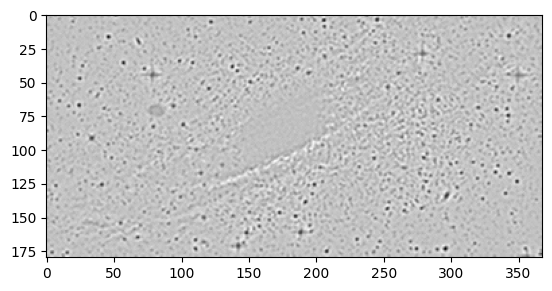

In [ ]:
log = cv2.GaussianBlur(img, (5,5), 0)
log = cv2.Laplacian(log, cv2.CV_64F)

plt.imshow(log, cmap='gray')

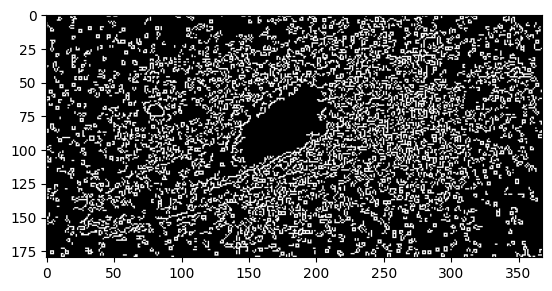

In [ ]:
edges = cv2.Canny(img, 100, 200)
plt.imshow(edges, cmap='gray')

(np.float64(-0.5), np.float64(367.5), np.float64(179.5), np.float64(-0.5))

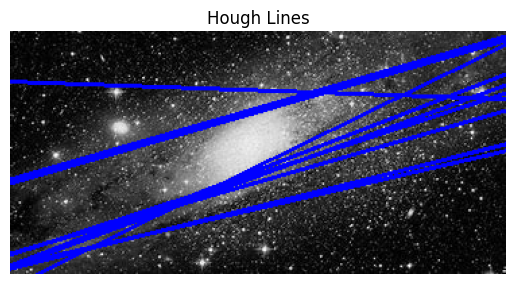

In [ ]:
img = cv2.imread('/content/image.jpg', 0)

# Improve edges
edges = cv2.Canny(img, 50, 150)

lines = cv2.HoughLines(edges, 1, np.pi/180, 120)

img_color = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)

# ✅ FIX: check if lines exist
if lines is not None:
    for line in lines[:10]:
        rho, theta = line[0]
        a, b = np.cos(theta), np.sin(theta)
        x0, y0 = a*rho, b*rho
        x1, y1 = int(x0 + 1000*(-b)), int(y0 + 1000*(a))
        x2, y2 = int(x0 - 1000*(-b)), int(y0 - 1000*(a))

        cv2.line(img_color, (x1,y1), (x2,y2), (0,0,255), 2)
else:
    print("No lines detected — try lowering threshold")

plt.imshow(img_color)
plt.title("Hough Lines")
plt.axis('off')